# Multi-Task Learning

- Shared backbone: ResNet-18 (pretrained on ImageNet)
- Task-specific heads:
  - Myopic maculopathy grade classification (CrossEntropy)
  - Age regression (MSE loss)
  - Sex classification (Binary CrossEntropy)

## Loss Balancing
GradNorm:

$$\mathcal{L}_{total} = w_1 \mathcal{L}_{grade} + w_2 \mathcal{L}_{age} + w_3 \mathcal{L}_{sex}$$

In [52]:
import os
import sys
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

from PIL import Image
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, cohen_kappa_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [53]:
DATA_ROOT = os.path.join("..", "Data")
TRAIN_IMG_DIR = os.path.join(DATA_ROOT, "Training", "Training_Images")
TRAIN_CSV = os.path.join(DATA_ROOT, "Training", "Training_LabelsDemographic.csv")
TEST_IMG_DIR = os.path.join(DATA_ROOT, "Testing", "Testing_Images")
TEST_CSV = os.path.join(DATA_ROOT, "Testing", "Testing_LabelDemographic.csv")

# CSVs
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")
print(f"\nGrade distribution (train):")
print(train_df["myopic_maculopathy_grade"].value_counts().sort_index())
print(f"\nMissing sex (train): {train_df['sex'].isnull().sum()}/{len(train_df)}")
print(f"Missing sex (test): {test_df['sex'].isnull().sum()}/{len(test_df)}")

Training samples: 1143
Testing samples: 248

Grade distribution (train):
myopic_maculopathy_grade
0    404
1    412
2    224
3     60
4     43
Name: count, dtype: int64

Missing sex (train): 153/1143
Missing sex (test): 33/248


In [54]:
class MyopicMaculopathyDataset(Dataset):
    """Dataset for multi-task learning."""

    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        # Precompute normalised age (z-score)
        self.age_mean = self.df["age"].mean()
        self.age_std = self.df["age"].std()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(self.img_dir, row["image"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Primary task: maculopathy grade (0-4)
        grade = torch.tensor(row["myopic_maculopathy_grade"], dtype=torch.long)

        # task 2: age (normalised)
        age_norm = (row["age"] - self.age_mean) / self.age_std
        age = torch.tensor(age_norm, dtype=torch.float32)

        # task 3: sex (binary, with validity mask)
        if pd.isna(row["sex"]):
            sex = torch.tensor(0.0, dtype=torch.float32)
            sex_valid = torch.tensor(0.0, dtype=torch.float32)
        else:
            sex = torch.tensor(1.0 if row["sex"] == "female" else 0.0, dtype=torch.float32)
            sex_valid = torch.tensor(1.0, dtype=torch.float32)

        return image, grade, age, sex, sex_valid

In [55]:
# image transforms
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# datasets
train_dataset = MyopicMaculopathyDataset(train_df, TRAIN_IMG_DIR, transform=train_transform)
test_dataset = MyopicMaculopathyDataset(test_df, TEST_IMG_DIR, transform=test_transform)

# training set age stats
test_dataset.age_mean = train_dataset.age_mean
test_dataset.age_std = train_dataset.age_std

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train batches: 36, Test batches: 8


### Visualisation of the sample images with their labels

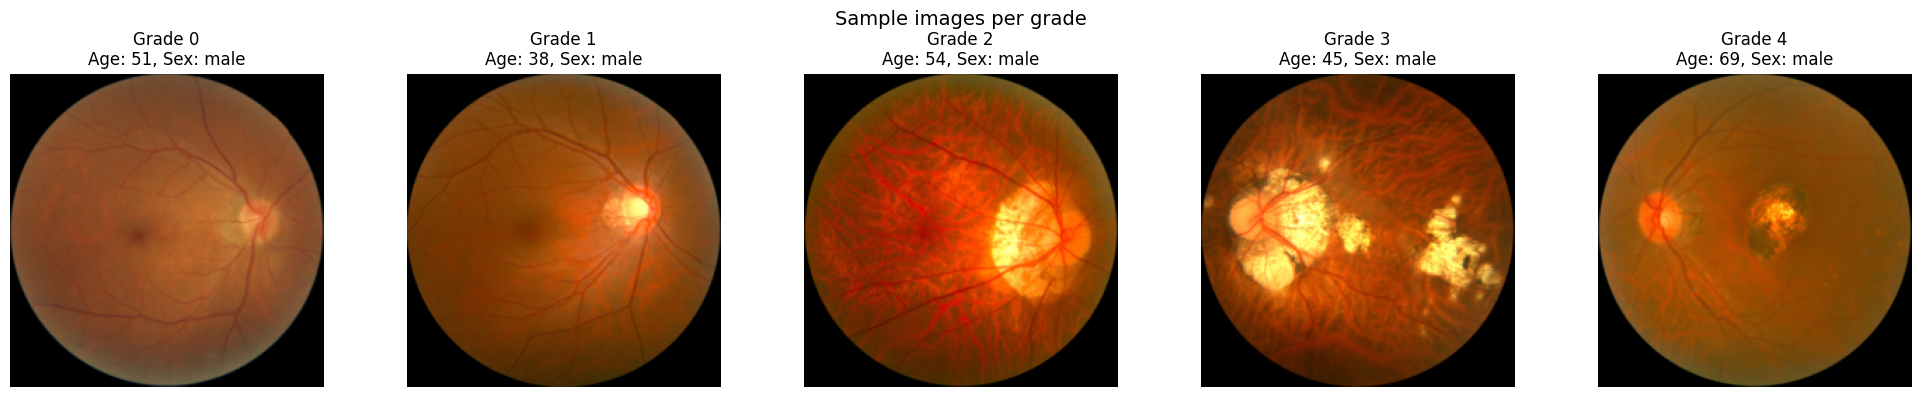

In [56]:
# one sample per grade (unnormalised)
vis_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for grade in range(5):
    idx = train_df[train_df["myopic_maculopathy_grade"] == grade].index[0]
    img_path = os.path.join(TRAIN_IMG_DIR, train_df.iloc[idx]["image"])
    img = vis_transform(Image.open(img_path).convert("RGB"))
    axes[grade].imshow(img.permute(1, 2, 0))
    axes[grade].set_title(f"Grade {grade}\nAge: {train_df.iloc[idx]['age']}, Sex: {train_df.iloc[idx]['sex']}")
    axes[grade].axis("off")
plt.suptitle("Sample images per grade", fontsize=14)
plt.tight_layout()
plt.show()

## Multi-Task Learning Model

In [57]:
class MultiTaskResNet(nn.Module):
    """Multi-task ResNet-18 with shared backbone and 3 task-specific heads."""

    def __init__(self, num_grades=5, pretrained=True):
        super(MultiTaskResNet, self).__init__()

        # shared backbone: ResNet-18 without the final FC layer
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
        self.shared_encoder = nn.Sequential(*list(backbone.children())[:-1]) # output: (B, 512, 1, 1)

        # grade classification head
        self.grade_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_grades),
        )

        # age regression head
        self.age_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

        # sex classification head
        self.sex_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        # Shared feature extraction
        features = self.shared_encoder(x) # (B, 512, 1, 1)
        features = features.view(features.size(0), -1) # (B, 512)

        # Task-specific predictions
        grade_logits = self.grade_head(features) # (B, 5)
        age_pred = self.age_head(features).squeeze(1) # (B,)
        sex_logits = self.sex_head(features).squeeze(1) # (B,)

        return grade_logits, age_pred, sex_logits

    def get_shared_params(self):
        return list(self.shared_encoder.parameters())

model = MultiTaskResNet(num_grades=5, pretrained=True).to(device)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Shared encoder params: {sum(p.numel() for p in model.shared_encoder.parameters()):,}")

Total parameters: 11,440,711
Shared encoder params: 11,176,512


### Loss Functions
- Grade: CrossEntropy loss (multi-class classification)
- Age: MSE loss (regression on z-score normalised age)
- Sex: Binary CrossEntropy with logits

In [58]:
# Loss functions for each task

# class weights for imbalanced grade distribution (inverse frequency)
grade_counts = train_df["myopic_maculopathy_grade"].value_counts().sort_index().values
class_weights = 1.0 / grade_counts
class_weights = class_weights / class_weights.sum() * len(class_weights)  # normalise so sum = num_classes
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Class weights: {class_weights}")

criterion_grade = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
criterion_age = nn.MSELoss()
criterion_sex = nn.BCEWithLogitsLoss(reduction="none")  # per-sample for masking


def compute_masked_sex_loss(sex_logits, sex_targets, sex_valid):
    """Compute sex loss only for samples with valid sex labels."""
    per_sample_loss = criterion_sex(sex_logits, sex_targets)
    masked_loss = per_sample_loss * sex_valid
    n_valid = sex_valid.sum()
    if n_valid > 0:
        return masked_loss.sum() / n_valid
    else:
        return torch.tensor(0.0, device=sex_logits.device, requires_grad=True)


Class weights: tensor([0.2511, 0.2462, 0.4529, 1.6907, 2.3591])


## Evaluation

In [59]:
def evaluate_model(model, dataloader):
    """Evaluate the model on grade classification."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, grades, ages, sexes, sex_valid in dataloader:
            images = images.to(device)
            grade_logits, _, _ = model(images)
            preds = grade_logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(grades.numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    kappa = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    return acc, f1, kappa


def full_evaluation(model, dataloader, dataset_name="Test"):
    """classification report and confusion matrix."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, grades, ages, sexes, sex_valid in dataloader:
            images = images.to(device)
            grade_logits, _, _ = model(images)
            all_preds.extend(grade_logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(grades.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    print(f" {dataset_name} Evaluation: ")
    print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
    print(f"Macro F1: {f1_score(all_labels, all_preds, average='macro', zero_division=0):.4f}")
    print(f"Quadratic Kappa: {cohen_kappa_score(all_labels, all_preds, weights='quadratic'):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(all_labels, all_preds,
          target_names=[f"Grade {i}" for i in range(5)], zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap="Blues")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=14)
    ax.set_xlabel("Predicted Grade")
    ax.set_ylabel("True Grade")
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_title(f"Confusion Matrix ({dataset_name} Set)")
    plt.tight_layout()
    plt.show()

    return all_preds, all_labels

## Training with GradNorm

In [60]:
def train_mtl_gradnorm(model, train_loader, test_loader, num_epochs=30, lr=1e-4, alpha=0.5):
    """Train the multi-task model using GradNorm with stability improvements."""
    num_tasks = 3

    task_weights = torch.ones(num_tasks, device=device, requires_grad=True)

    head_params = (
        list(model.grade_head.parameters())
        + list(model.age_head.parameters())
        + list(model.sex_head.parameters())
    )
    optimizer_model = optim.AdamW([
        {"params": model.shared_encoder.parameters(), "lr": lr * 0.1},
        {"params": head_params, "lr": lr},
    ], weight_decay=1e-4)
    optimizer_weights = optim.Adam([task_weights], lr=5e-4)

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer_model, T_0=10, T_mult=2)

    grad_norm_loss_fn = nn.L1Loss()
    shared_layer = list(model.shared_encoder.parameters())[-2]

    history = {
        "train_loss": [], "grade_loss": [], "age_loss": [], "sex_loss": [],
        "w_grade": [], "w_age": [], "w_sex": [],
        "test_acc": [], "test_f1": [], "test_kappa": [],
    }

    L0 = [None, None, None]
    best_kappa = -1.0
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        epoch_losses = {"total": 0, "grade": 0, "age": 0, "sex": 0}
        n_batches = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", file=sys.stdout)
        for images, grades, ages, sexes, sex_valid in pbar:
            images = images.to(device)
            grades = grades.to(device)
            ages = ages.to(device)
            sexes = sexes.to(device)
            sex_valid = sex_valid.to(device)

            grade_logits, age_pred, sex_logits = model(images)

            loss_grade = criterion_grade(grade_logits, grades)
            loss_age = criterion_age(age_pred, ages)
            loss_sex = compute_masked_sex_loss(sex_logits, sexes, sex_valid)
            losses = [loss_grade, loss_age, loss_sex]

            if L0[0] is None:
                L0 = [l.detach().clone() for l in losses]

            # model loss (detached weights: gradients flow to model only)
            model_loss = sum(task_weights[i].detach() * losses[i] for i in range(num_tasks))

            # GradNorm: compute per-task gradient norms on last shared layer
            G_norms = []
            for i in range(num_tasks):
                g = torch.autograd.grad(
                    task_weights[i] * losses[i], shared_layer,
                    retain_graph=True, create_graph=True
                )[0]
                G_norms.append(torch.norm(g, 2))

            G_avg = sum(G_norms) / num_tasks

            r = [losses[i].detach() / (L0[i] + 1e-8) for i in range(num_tasks)]
            r_avg = sum(r) / num_tasks
            r_rel = [r[i] / (r_avg + 1e-8) for i in range(num_tasks)]
            G_targets = [G_avg.detach() * (r_rel[i] ** alpha) for i in range(num_tasks)]

            gradnorm_loss = sum(
                grad_norm_loss_fn(G_norms[i], G_targets[i]) for i in range(num_tasks)
            )

            # single combined backward: avoids multiple .backward() calls and in-place conflicts
            optimizer_model.zero_grad()
            optimizer_weights.zero_grad()
            (model_loss + gradnorm_loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer_model.step()
            optimizer_weights.step()

            with torch.no_grad():
                task_weights.data = task_weights.data / task_weights.data.sum() * num_tasks
                task_weights.data = task_weights.data.clamp(min=0.1)

            epoch_losses["total"] += model_loss.item()
            epoch_losses["grade"] += loss_grade.item()
            epoch_losses["age"] += loss_age.item()
            epoch_losses["sex"] += loss_sex.item()
            n_batches += 1

            pbar.set_postfix({
                "loss": f"{model_loss.item():.3f}",
                "w": f"[{task_weights[0].item():.2f}, {task_weights[1].item():.2f}, {task_weights[2].item():.2f}]"
            })

        scheduler.step()

        for k in epoch_losses:
            epoch_losses[k] /= n_batches
        history["train_loss"].append(epoch_losses["total"])
        history["grade_loss"].append(epoch_losses["grade"])
        history["age_loss"].append(epoch_losses["age"])
        history["sex_loss"].append(epoch_losses["sex"])
        history["w_grade"].append(task_weights[0].item())
        history["w_age"].append(task_weights[1].item())
        history["w_sex"].append(task_weights[2].item())

        acc, f1, kappa = evaluate_model(model, test_loader)
        history["test_acc"].append(acc)
        history["test_f1"].append(f1)
        history["test_kappa"].append(kappa)

        if kappa > best_kappa:
            best_kappa = kappa
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f" Losses - Total: {epoch_losses['total']:.4f}, "
              f"Grade: {epoch_losses['grade']:.4f}, Age: {epoch_losses['age']:.4f}, "
              f"Sex: {epoch_losses['sex']:.4f}")
        print(f" Weights - Grade: {task_weights[0].item():.3f}, "
              f"Age: {task_weights[1].item():.3f}, Sex: {task_weights[2].item():.3f}")
        print(f" Test Acc: {acc:.4f}, F1: {f1:.4f}, Kappa: {kappa:.4f}"
              f"{'  *best*' if kappa == best_kappa else ''}")

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"\nRestored best model (Kappa: {best_kappa:.4f})")

    return history


## Training the Multi-Task Model

In [61]:
NUM_EPOCHS = 40

model = MultiTaskResNet(num_grades=5, pretrained=True).to(device)
history = train_mtl_gradnorm(
    model, train_loader, test_loader,
    num_epochs=NUM_EPOCHS, lr=3e-4, alpha=0.5
)


Epoch 1/40: 100%|██████████| 36/36 [01:09<00:00,  1.93s/it, loss=2.621, w=[1.00, 0.98, 1.02]]
 Losses - Total: 3.1500, Grade: 1.6513, Age: 0.8752, Sex: 0.6237
 Weights - Grade: 1.002, Age: 0.982, Sex: 1.016
 Test Acc: 0.5766, F1: 0.5067, Kappa: 0.7756  *best*
Epoch 2/40: 100%|██████████| 36/36 [01:08<00:00,  1.91s/it, loss=2.574, w=[1.00, 0.97, 1.03]]
 Losses - Total: 2.5897, Grade: 1.4215, Age: 0.5793, Sex: 0.5888
 Weights - Grade: 0.996, Age: 0.971, Sex: 1.033
 Test Acc: 0.7137, F1: 0.5546, Kappa: 0.7905  *best*
Epoch 3/40: 100%|██████████| 36/36 [01:09<00:00,  1.92s/it, loss=2.351, w=[0.99, 0.96, 1.05]]
 Losses - Total: 2.3836, Grade: 1.3252, Age: 0.4899, Sex: 0.5703
 Weights - Grade: 0.992, Age: 0.957, Sex: 1.052
 Test Acc: 0.7540, F1: 0.7115, Kappa: 0.8653  *best*
Epoch 4/40: 100%|██████████| 36/36 [01:09<00:00,  1.92s/it, loss=2.352, w=[0.99, 0.94, 1.07]]
 Losses - Total: 2.2392, Grade: 1.2550, Age: 0.4338, Sex: 0.5527
 Weights - Grade: 0.986, Age: 0.943, Sex: 1.071
 Test Acc: 0.

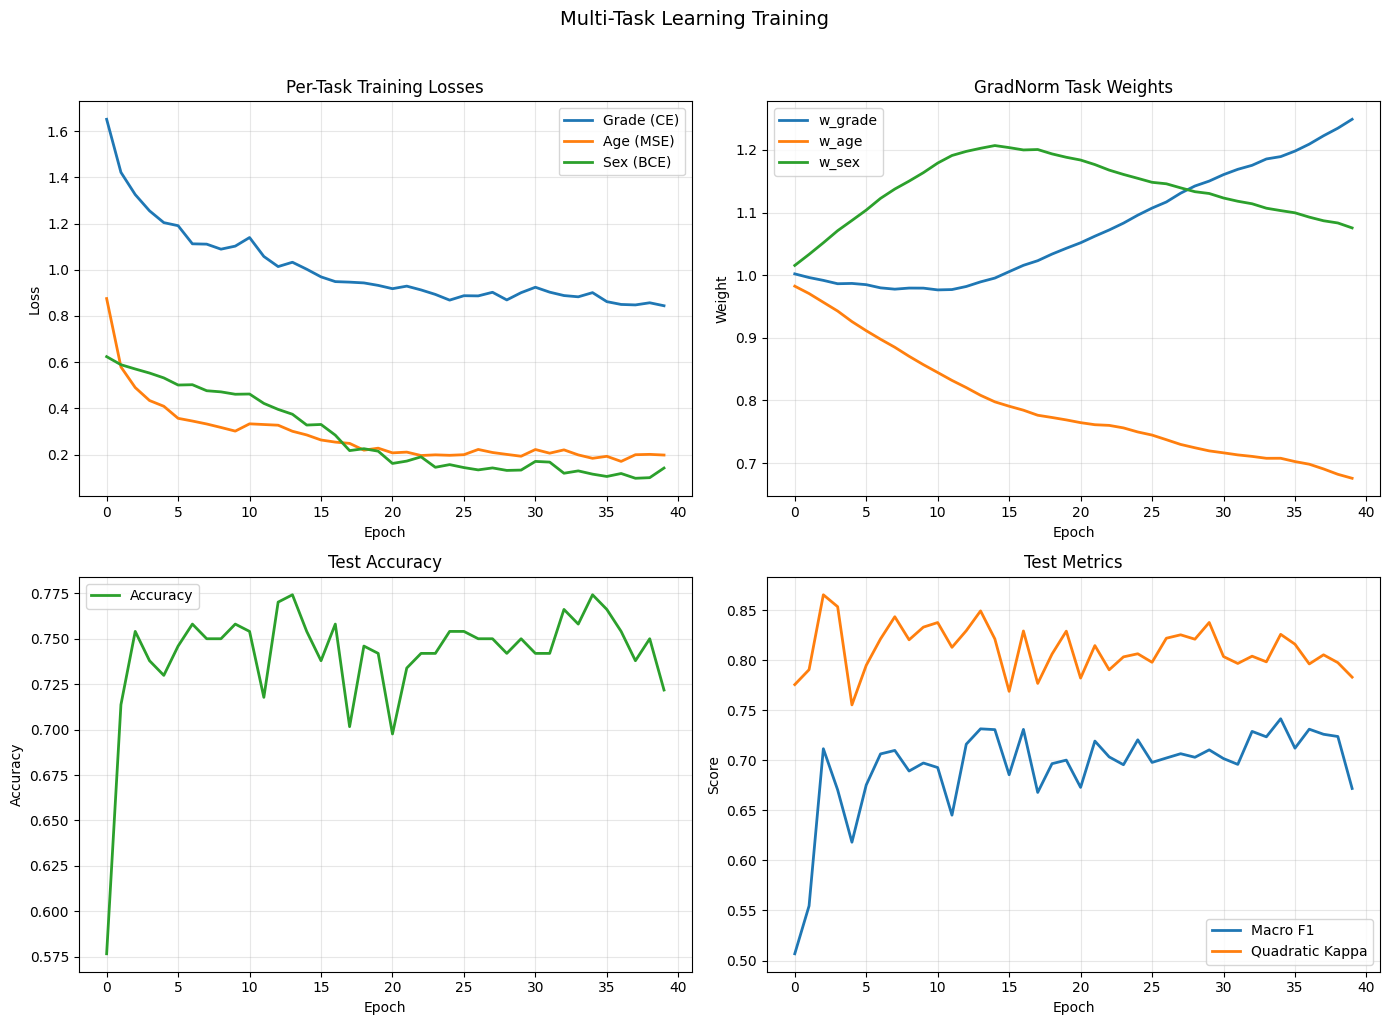

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Per-task training losses
axes[0, 0].plot(history["grade_loss"], label="Grade (CE)", linewidth=2)
axes[0, 0].plot(history["age_loss"], label="Age (MSE)", linewidth=2)
axes[0, 0].plot(history["sex_loss"], label="Sex (BCE)", linewidth=2)
axes[0, 0].set_title("Per-Task Training Losses")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# GradNorm learned task weights
axes[0, 1].plot(history["w_grade"], label="w_grade", linewidth=2)
axes[0, 1].plot(history["w_age"], label="w_age", linewidth=2)
axes[0, 1].plot(history["w_sex"], label="w_sex", linewidth=2)
axes[0, 1].set_title("GradNorm Task Weights")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Weight")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Test accuracy
axes[1, 0].plot(history["test_acc"], label="Accuracy", linewidth=2, color="tab:green")
axes[1, 0].set_title("Test Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Test F1 and Kappa
axes[1, 1].plot(history["test_f1"], label="Macro F1", linewidth=2)
axes[1, 1].plot(history["test_kappa"], label="Quadratic Kappa", linewidth=2)
axes[1, 1].set_title("Test Metrics")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Score")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("Multi-Task Learning Training", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Final Evaluation on Test Set

 Test Evaluation: 
Accuracy: 0.7540
Macro F1: 0.7115
Quadratic Kappa: 0.8653

Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.80      0.88      0.83        80
     Grade 1       0.68      0.73      0.70        78
     Grade 2       0.91      0.66      0.77        65
     Grade 3       0.50      0.58      0.54        12
     Grade 4       0.67      0.77      0.71        13

    accuracy                           0.75       248
   macro avg       0.71      0.72      0.71       248
weighted avg       0.77      0.75      0.75       248



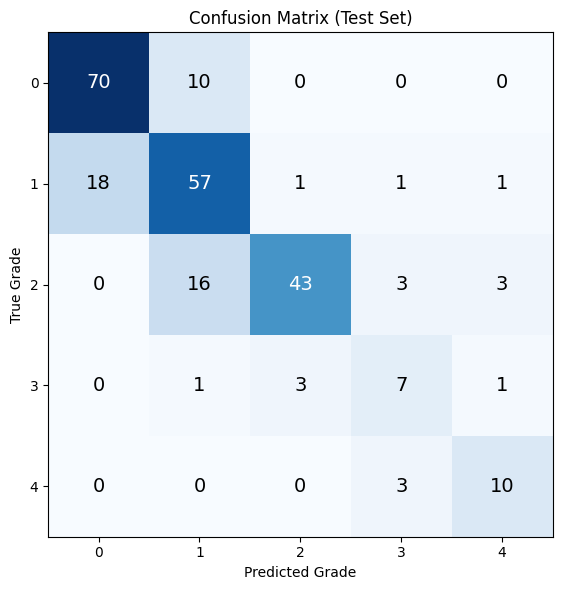

In [63]:
preds, labels = full_evaluation(model, test_loader, dataset_name="Test")

## Task Evaluation

Evaluate age regression (MAE) and sex classification (accuracy) on the test set.

Task Evaluation (Test Set)
Age regression MAE: 7.00 years
Sex classification accuracy: 0.6837 (215 valid samples)


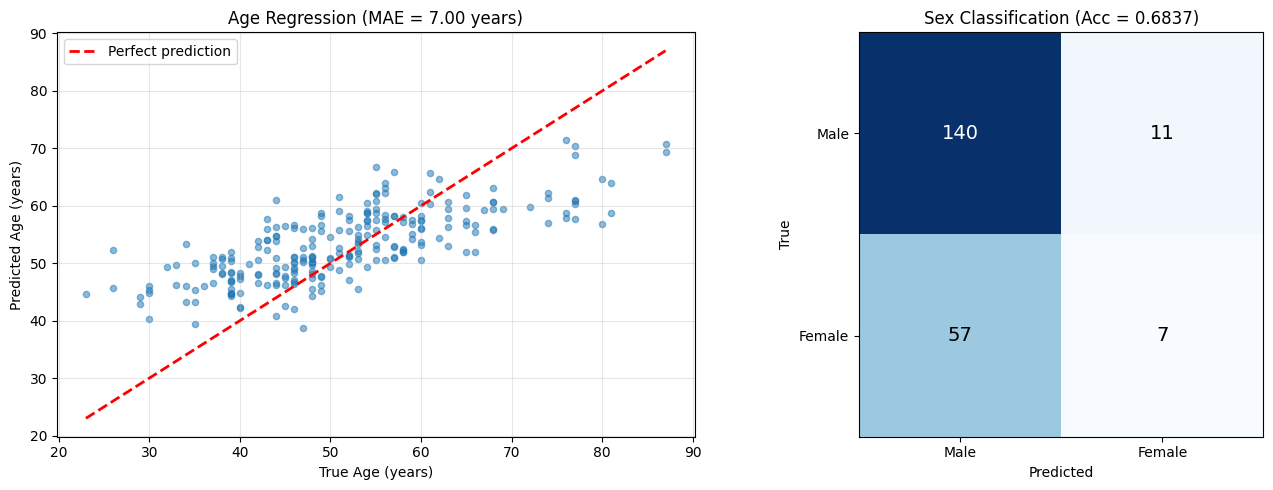

In [64]:
def evaluate_tasks(model, dataloader, age_mean, age_std):
    """Evaluate task performance (age MAE, sex accuracy)."""
    model.eval()
    age_preds, age_labels = [], []
    sex_preds, sex_labels = [], []

    with torch.no_grad():
        for images, grades, ages, sexes, sex_valid in dataloader:
            images = images.to(device)
            _, age_pred, sex_logits = model(images)

            # de-normalise age predictions
            age_pred_years = age_pred.cpu().numpy() * age_std + age_mean
            age_true_years = ages.numpy() * age_std + age_mean
            age_preds.extend(age_pred_years)
            age_labels.extend(age_true_years)

            # sex (only valid samples)
            valid_mask = sex_valid.bool()
            if valid_mask.any():
                sex_pred = (sex_logits.cpu() > 0).float()
                sex_preds.extend(sex_pred[valid_mask].numpy())
                sex_labels.extend(sexes[valid_mask].numpy())

    age_preds = np.array(age_preds)
    age_labels = np.array(age_labels)
    sex_preds = np.array(sex_preds)
    sex_labels = np.array(sex_labels)

    age_mae = np.mean(np.abs(age_preds - age_labels))
    sex_acc = accuracy_score(sex_labels, sex_preds) if len(sex_labels) > 0 else float('nan')

    print(f"Task Evaluation (Test Set)")
    print(f"Age regression MAE: {age_mae:.2f} years")
    print(f"Sex classification accuracy: {sex_acc:.4f} ({len(sex_labels)} valid samples)")

    # age prediction scatter plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(age_labels, age_preds, alpha=0.5, s=20)
    min_age, max_age = min(age_labels.min(), age_preds.min()), max(age_labels.max(), age_preds.max())
    axes[0].plot([min_age, max_age], [min_age, max_age], 'r--', linewidth=2, label='Perfect prediction')
    axes[0].set_xlabel('True Age (years)')
    axes[0].set_ylabel('Predicted Age (years)')
    axes[0].set_title(f'Age Regression (MAE = {age_mae:.2f} years)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # sex confusion matrix
    if len(sex_labels) > 0:
        cm_sex = confusion_matrix(sex_labels, sex_preds)
        im = axes[1].imshow(cm_sex, cmap='Blues')
        for i in range(cm_sex.shape[0]):
            for j in range(cm_sex.shape[1]):
                color = 'white' if cm_sex[i, j] > cm_sex.max() / 2 else 'black'
                axes[1].text(j, i, str(cm_sex[i, j]), ha='center', va='center', color=color, fontsize=14)
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('True')
        axes[1].set_xticks([0, 1])
        axes[1].set_yticks([0, 1])
        axes[1].set_xticklabels(['Male', 'Female'])
        axes[1].set_yticklabels(['Male', 'Female'])
        axes[1].set_title(f'Sex Classification (Acc = {sex_acc:.4f})')

    plt.tight_layout()
    plt.show()

    return age_mae, sex_acc


age_mae, sex_acc = evaluate_tasks(
    model, test_loader,
    age_mean=train_dataset.age_mean,
    age_std=train_dataset.age_std
)

## Comparison: Single-Task vs Multi-Task

In [65]:
class SingleTaskResNet(nn.Module):
    """Single-task ResNet-18 baseline (grade classification only)."""

    def __init__(self, num_grades=5, pretrained=True):
        super(SingleTaskResNet, self).__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
        num_ftrs = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Linear(num_ftrs, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_grades),
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)


def train_single_task(model_st, train_loader, test_loader, num_epochs=40, lr=3e-4):
    """Single-task baseline with same improvements for fair comparison."""
    optimizer = optim.AdamW([
        {"params": model_st.backbone.parameters(), "lr": lr * 0.1},
        {"params": model_st.head.parameters(), "lr": lr},
    ], weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

    history_st = {"train_loss": [], "test_acc": [], "test_f1": [], "test_kappa": []}
    best_kappa = -1.0
    best_state = None

    for epoch in range(num_epochs):
        model_st.train()
        running_loss = 0
        n_batches = 0

        pbar = tqdm(train_loader, desc=f"ST Epoch {epoch+1}/{num_epochs}", file=sys.stdout)
        for images, grades, _, _, _ in pbar:
            images, grades = images.to(device), grades.to(device)
            logits = model_st(images)
            loss = criterion_grade(logits, grades)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_st.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()
            n_batches += 1
            pbar.set_postfix({"loss": f"{loss.item():.3f}"})

        scheduler.step()
        history_st["train_loss"].append(running_loss / n_batches)

        model_st.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, grades, _, _, _ in test_loader:
                images = images.to(device)
                logits = model_st(images)
                all_preds.extend(logits.argmax(dim=1).cpu().numpy())
                all_labels.extend(grades.numpy())

        all_preds, all_labels = np.array(all_preds), np.array(all_labels)
        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
        kappa = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
        history_st["test_acc"].append(acc)
        history_st["test_f1"].append(f1)
        history_st["test_kappa"].append(kappa)

        if kappa > best_kappa:
            best_kappa = kappa
            best_state = {k: v.cpu().clone() for k, v in model_st.state_dict().items()}

        print(f" Loss: {running_loss/n_batches:.4f}, Acc: {acc:.4f}, F1: {f1:.4f}, Kappa: {kappa:.4f}"
              f"{'  *best*' if kappa == best_kappa else ''}")

    if best_state is not None:
        model_st.load_state_dict(best_state)
        print(f"\nRestored best single-task model (Kappa: {best_kappa:.4f})")

    return history_st


model_st = SingleTaskResNet(num_grades=5, pretrained=True).to(device)
history_st = train_single_task(model_st, train_loader, test_loader, num_epochs=NUM_EPOCHS)


ST Epoch 1/40: 100%|██████████| 36/36 [01:11<00:00,  1.98s/it, loss=1.376]
 Loss: 1.6004, Acc: 0.7016, F1: 0.6349, Kappa: 0.7849  *best*
ST Epoch 2/40: 100%|██████████| 36/36 [01:08<00:00,  1.91s/it, loss=1.151]
 Loss: 1.3258, Acc: 0.6774, F1: 0.5973, Kappa: 0.7111
ST Epoch 3/40: 100%|██████████| 36/36 [01:12<00:00,  2.01s/it, loss=1.588]
 Loss: 1.2348, Acc: 0.7419, F1: 0.6956, Kappa: 0.7881  *best*
ST Epoch 4/40: 100%|██████████| 36/36 [01:09<00:00,  1.94s/it, loss=1.564]
 Loss: 1.1960, Acc: 0.7782, F1: 0.7417, Kappa: 0.8407  *best*
ST Epoch 5/40: 100%|██████████| 36/36 [01:09<00:00,  1.94s/it, loss=1.083]
 Loss: 1.1129, Acc: 0.7944, F1: 0.7703, Kappa: 0.8695  *best*
ST Epoch 6/40: 100%|██████████| 36/36 [01:09<00:00,  1.93s/it, loss=1.324]
 Loss: 1.0752, Acc: 0.7903, F1: 0.7661, Kappa: 0.8516
ST Epoch 7/40: 100%|██████████| 36/36 [01:09<00:00,  1.94s/it, loss=0.882]
 Loss: 1.0430, Acc: 0.7742, F1: 0.7440, Kappa: 0.8282
ST Epoch 8/40: 100%|██████████| 36/36 [01:09<00:00,  1.92s/it, lo

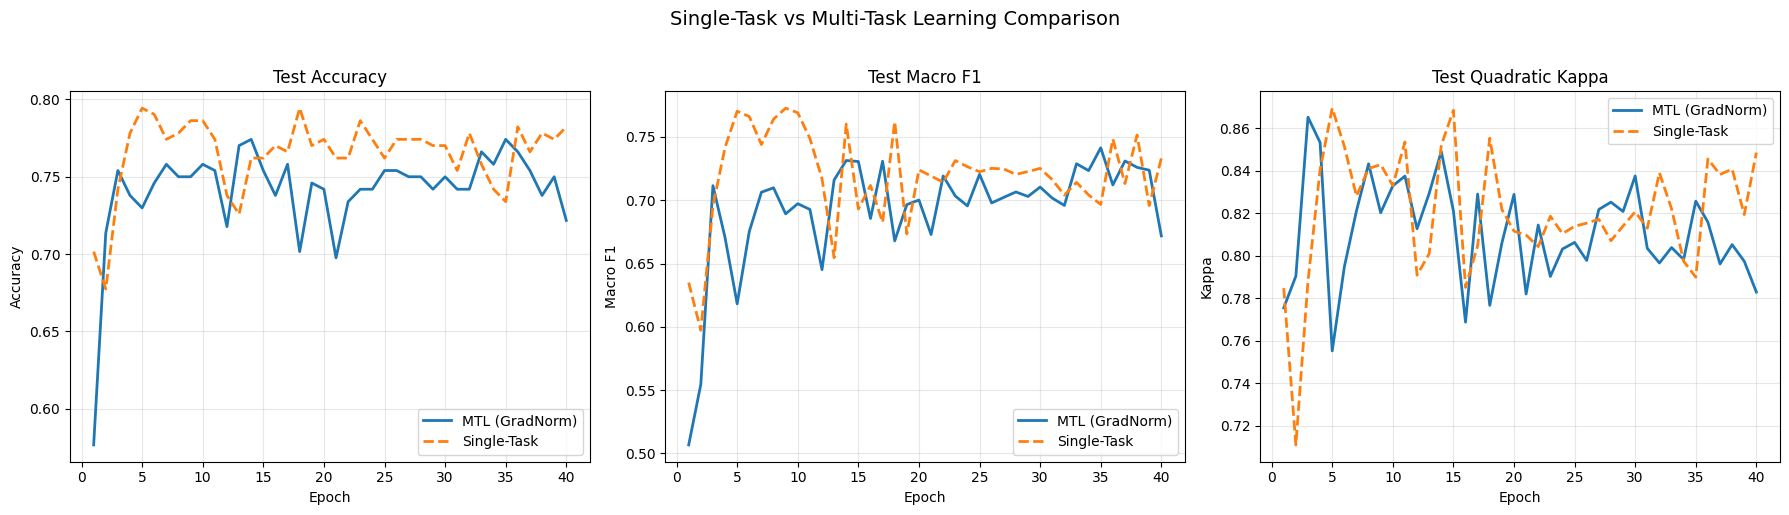

  Final Epoch Comparison
Metric                Single-Task          MTL
--------------------------------------------------
Accuracy                   0.7823       0.7218
Macro F1                   0.7331       0.6718
Quadratic Kappa            0.8486       0.7830


In [66]:
# comparison plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs, history["test_acc"], label="MTL (GradNorm)", linewidth=2)
axes[0].plot(epochs, history_st["test_acc"], label="Single-Task", linewidth=2, linestyle="--")
axes[0].set_title("Test Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history["test_f1"], label="MTL (GradNorm)", linewidth=2)
axes[1].plot(epochs, history_st["test_f1"], label="Single-Task", linewidth=2, linestyle="--")
axes[1].set_title("Test Macro F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history["test_kappa"], label="MTL (GradNorm)", linewidth=2)
axes[2].plot(epochs, history_st["test_kappa"], label="Single-Task", linewidth=2, linestyle="--")
axes[2].set_title("Test Quadratic Kappa")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Kappa")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Single-Task vs Multi-Task Learning Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary
print(f"  Final Epoch Comparison")
print(f"{'Metric':<20} {'Single-Task':>12} {'MTL':>12}")
print(f"{'-'*50}")
print(f"{'Accuracy':<20} {history_st['test_acc'][-1]:>12.4f} {history['test_acc'][-1]:>12.4f}")
print(f"{'Macro F1':<20} {history_st['test_f1'][-1]:>12.4f} {history['test_f1'][-1]:>12.4f}")
print(f"{'Quadratic Kappa':<20} {history_st['test_kappa'][-1]:>12.4f} {history['test_kappa'][-1]:>12.4f}")

In [67]:
save_path = os.path.join("..", "models")
os.makedirs(save_path, exist_ok=True)

torch.save(model.state_dict(), os.path.join(save_path, "mtl_resnet18_gradnorm.pt"))

import json
with open(os.path.join(save_path, "mtl_history.json"), "w") as f:
    json.dump(history, f)
with open(os.path.join(save_path, "st_history.json"), "w") as f:
    json.dump(history_st, f)